<a href="https://colab.research.google.com/github/nigamarchita28/Seasonal-Agriculture-Performance-Analysis/blob/main/Seasonal_Agriculture_Performance_Analysis_(5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seasonal Agriculture Performance Analysis
**VOIS AICTE Batch 1 (2026-2027) | Major Project | Data Visualization**

---
### Problem statement
Agricultural performance changes from one season to another because of differences in weather, farming practice, resource use and market conditions. Raw data does not show *how* performance changes. This notebook analyzes a dataset of **4,000 farms across 8 Indian states, 8 crops and 3 seasons (Kharif, Rabi, Zaid)** to find seasonal patterns, relationships and unusual observations, and turns them into recommendations.

### Questions this notebook answers
1. How do **yield, revenue, cost and profit** differ across seasons?
2. Which **environmental conditions** change between seasons, and how do they relate to outcomes?
3. Do **resource use** (fertilizer, pesticide, water, cost) and **water efficiency** differ by season?
4. How does **disease and pest risk** change by season, and what drives it?
5. Is the seasonal pattern **consistent** across crops, states and irrigation methods?
6. Are the differences **statistically significant**, and what looks **unusual**?

### Notebook outline
1. Setup and loading the data  
2. Understanding the dataset  
3. Data cleaning and preparation  
4. Seasonal analysis (yield, economics, environment, resources, disease risk)  
5. Relationships and correlations  
6. Consistency across irrigation methods and states  
7. Statistical tests  
8. Unusual patterns  
9. Conclusions, recommendations and limitations

## 1. Setup and loading the data

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

SEASONS = ["Kharif", "Rabi", "Zaid"]
PALETTE = {"Kharif": "#3A7D44", "Rabi": "#E9A23B", "Zaid": "#C8553D"}
print("Libraries loaded.")

Libraries loaded.


In [2]:
# ---- Load the dataset (works locally, on Colab, or straight from GitHub) ----
FILE = "seasonal_agriculture_performance_dataset.csv"
DATA_URL = ""   # optional: paste the "raw" GitHub link of the CSV here

if os.path.exists(FILE):
    source = FILE
elif DATA_URL:
    source = DATA_URL
else:
    from google.colab import files          # only runs on Google Colab
    print("Choose the dataset CSV file to upload...")
    uploaded = files.upload()
    source = list(uploaded.keys())[0]      # use whatever file name was uploaded

df_raw = pd.read_csv(source)
df = df_raw.copy()          # work on a copy, keep the raw data untouched
print("Rows:", df.shape[0], "| Columns:", df.shape[1])
df.head()

Choose the dataset CSV file to upload...


Saving seasonal_agriculture_performance_dataset (1).csv to seasonal_agriculture_performance_dataset (1).csv
Rows: 4000 | Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 2. Understanding the dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.89,4.22,0.50,4.26,7.90,11.65,15.00
Rainfall_mm,3952.0,601.15,288.93,80.00,370.20,582.00,834.95,1395.20
Avg_Temperature_C,4000.0,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.0,63.21,11.96,25.00,54.78,63.00,71.90,95.00
Sunlight_Hours_Day,4000.0,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.0,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,3960.0,26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,4000.0,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.0,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.0,104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [5]:
print("Farms per season:")
print(df["Season"].value_counts().reindex(SEASONS).to_string())
print("\nStates:", ", ".join(sorted(df["State"].unique())))
print("Crops :", ", ".join(sorted(df["Crop"].unique())))
print("Irrigation methods:", ", ".join(sorted(df["Irrigation_Method"].unique())))
print()
pd.crosstab(df["Crop"], df["Season"])[SEASONS]

Farms per season:
Season
Kharif    1779
Rabi      1627
Zaid       594

States: Andhra Pradesh, Gujarat, Karnataka, Madhya Pradesh, Maharashtra, Punjab, Tamil Nadu, Telangana
Crops : Chilli, Cotton, Groundnut, Maize, Pulses, Rice, Sugarcane, Wheat
Irrigation methods: Drip, Flood, Rainfed, Sprinkler



Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


**What the dataset contains.** Each row is one farm in one season. The columns fall into five groups:

| Group | Columns |
|---|---|
| Location and crop | State, District, Crop, Season, Farm_Area_Hectares |
| Environment | Rainfall_mm, Avg_Temperature_C, Humidity_pct, Sunlight_Hours_Day, Soil_pH, Soil_Moisture_pct |
| Farming practice | Nitrogen, Phosphorus, Potassium, Fertilizer, Pesticide, Irrigation_Method, Seed_Quality_Score |
| Output and economics | Yield_Tonnes_Ha, Production_Tonnes, Market_Price_INR_Tonne, Total_Cost_INR, Revenue_INR, Profit_INR |
| Water and risk | Water_Used_m3, Water_Efficiency_t_per_1000m3, Disease_Pest_Risk_pct |

Each crop has a broadly similar number of farms in every season, so seasons can be compared fairly.

## 3. Data cleaning and preparation
### 3.1 Missing values and duplicates

In [6]:
missing = df.isna().sum()
missing = missing[missing > 0].to_frame("Missing")
missing["Percent"] = (missing["Missing"] / len(df) * 100).round(2)
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Farm_IDs:", df["Farm_ID"].duplicated().sum())
missing

Duplicate rows: 0
Duplicate Farm_IDs: 0


,Missing,Percent
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


Three columns have missing values: `Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha`. There are no duplicates.

* **Yield** can be recovered exactly instead of dropped, because `Yield = Production / Farm Area`. First we verify that this relationship holds in the complete rows.
* **Rainfall and soil moisture** cannot be calculated from other columns. They vary strongly with season, so we fill them with the **median of the same season** (a global median would blur the seasonal differences we are studying).

In [7]:
# Check that Yield x Area = Production in rows where yield is present
ok = df.dropna(subset=["Yield_Tonnes_Ha"])
rel_err = (ok["Yield_Tonnes_Ha"] * ok["Farm_Area_Hectares"] - ok["Production_Tonnes"]).abs() / ok["Production_Tonnes"]
print(f"Yield x Area vs Production: median error {rel_err.median():.4%}, 99th percentile {rel_err.quantile(.99):.2%}")

# Other internal-consistency checks
print("Profit = Revenue - Cost holds for all rows:", ((df["Revenue_INR"] - df["Total_Cost_INR"]) == df["Profit_INR"]).all())
wu = df["Production_Tonnes"] / (df["Water_Used_m3"] / 1000)
print("Water efficiency matches Production / water used:", np.allclose(wu, df["Water_Efficiency_t_per_1000m3"], atol=0.01))

Yield x Area vs Production: median error 0.0173%, 99th percentile 0.53%
Profit = Revenue - Cost holds for all rows: True
Water efficiency matches Production / water used: True


In [8]:
# 1) Recover missing yield from production and area
n_yield = df["Yield_Tonnes_Ha"].isna().sum()
df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(df["Production_Tonnes"] / df["Farm_Area_Hectares"]).round(2)

# 2) Fill rainfall and soil moisture with the median of the same season
for col in ["Rainfall_mm", "Soil_Moisture_pct"]:
    df[col] = df[col].fillna(df.groupby("Season")[col].transform("median"))

print(f"Yield values recovered from Production / Area: {n_yield}")
print("Missing values left:", int(df.isna().sum().sum()))

Yield values recovered from Production / Area: 32
Missing values left: 0


### 3.2 Outliers and data-quality checks

In [9]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())

crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].agg(Farms="count", Median="median", Min="min", Max="max")
crop_yield["IQR_outliers"] = df.groupby("Crop")["Yield_Tonnes_Ha"].apply(iqr_outliers)
crop_yield.sort_values("Median", ascending=False).round(2)

,Farms,Median,Min,Max,IQR_outliers
Crop,,,,,
Sugarcane,305,48.03,1.39,101.44,0
Maize,551,2.85,0.30,6.08,0
Rice,690,2.46,0.30,5.70,0
Wheat,614,2.22,0.30,4.56,0
Chilli,412,1.56,0.30,3.90,0
Groundnut,424,1.40,0.30,3.02,0
Cotton,508,1.24,0.30,2.90,1
Pulses,496,0.94,0.30,2.09,0


In [10]:
# District / State consistency
dist_states = df.groupby("District")["State"].nunique()
print(f"Districts: {dist_states.size} | listed under more than one state: {(dist_states > 1).sum()}")
print("Rajkot appears under:", df.loc[df['District'] == 'Rajkot', 'State'].nunique(), "different states (in reality it is only in Gujarat)")

# Yield floor check
floor = (df["Yield_Tonnes_Ha"] <= 0.30).sum()
print(f"Farms with yield at the 0.30 t/ha minimum: {floor} ({floor/len(df):.1%}) -> yield looks capped at 0.30")

Districts: 10 | listed under more than one state: 10
Rajkot appears under: 8 different states (in reality it is only in Gujarat)
Farms with yield at the 0.30 t/ha minimum: 223 (5.6%) -> yield looks capped at 0.30


**Decisions from these checks**

* **Sugarcane yields about 47 t/ha while other crops give 1 to 3 t/ha.** This is genuine (sugarcane is a high-tonnage crop), not an error. But it means raw yields cannot be averaged across crops. We therefore build a **Yield Index** (each farm's yield divided by the median yield of its crop) so different crops can be compared together. Values above 1 are above the crop's normal yield.
* Extreme values inside each crop are few and plausible, so **no rows are removed**. We use medians and non-parametric tests where distributions are skewed.
* **District names do not match their states**: all 10 districts appear under several states (for example Rajkot appears under all 8). District is therefore **not used**; all regional analysis is at **State** level.
* **About 5.6% of farms have a yield of exactly 0.30 t/ha**, which suggests the data was capped at a minimum of 0.30. These are kept, but it means very poor yields are slightly understated.

### 3.3 Feature engineering

In [11]:
crop_median_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].transform("median")
crop_median_weff  = df.groupby("Crop")["Water_Efficiency_t_per_1000m3"].transform("median")

df["Yield_Index"]            = df["Yield_Tonnes_Ha"] / crop_median_yield             # 1.0 = typical for that crop
df["Water_Efficiency_Index"] = df["Water_Efficiency_t_per_1000m3"] / crop_median_weff
df["Loss_Making"]            = (df["Profit_INR"] < 0).astype(int)                    # 1 = farm made a loss
df["Cost_per_Ha"]            = df["Total_Cost_INR"] / df["Farm_Area_Hectares"]
df["Profit_per_Ha"]          = df["Profit_INR"] / df["Farm_Area_Hectares"]
df["Water_per_Ha"]           = df["Water_Used_m3"] / df["Farm_Area_Hectares"]

df["Season"] = pd.Categorical(df["Season"], categories=SEASONS, ordered=True)
df[["Crop", "Season", "Yield_Tonnes_Ha", "Yield_Index", "Profit_INR", "Loss_Making", "Cost_per_Ha", "Water_per_Ha"]].head()

,Crop,Season,Yield_Tonnes_Ha,Yield_Index,Profit_INR,Loss_Making,Cost_per_Ha,Water_per_Ha
0,Wheat,Kharif,2.46,1.110609,-11852,1,80494.339623,447.169811
1,Maize,Kharif,0.30,0.105263,-451950,1,75398.315467,758.499234
2,Pulses,Rabi,0.52,0.553191,-124744,1,64858.024691,262.345679
3,Rice,Kharif,1.84,0.747967,-95704,1,65876.444444,852.000000
4,Maize,Zaid,2.21,0.775439,-144352,1,80275.296912,780.760095


## 4. Seasonal analysis
### 4.1 Season overview

In [12]:
season_summary = df.groupby("Season", observed=True).agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield_Index=("Yield_Index", "mean"),
    Avg_Revenue_INR=("Revenue_INR", "mean"),
    Avg_Cost_INR=("Total_Cost_INR", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Median_Profit_INR=("Profit_INR", "median"),
    Loss_Making_Pct=("Loss_Making", "mean"),
    Avg_Disease_Risk_Pct=("Disease_Pest_Risk_pct", "mean"),
)
season_summary["Loss_Making_Pct"] = season_summary["Loss_Making_Pct"] * 100
season_summary.round(2)

,Farms,Avg_Yield_Index,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Median_Profit_INR,Loss_Making_Pct,Avg_Disease_Risk_Pct
Season,,,,,,,,
Kharif,1779,1.08,710719.06,531804.41,178914.65,38808.0,42.21,54.47
Rabi,1627,0.93,601526.05,513836.58,87689.47,-3187.0,51.14,40.48
Zaid,594,0.77,519171.90,543976.73,-24804.82,-62144.0,64.48,38.22


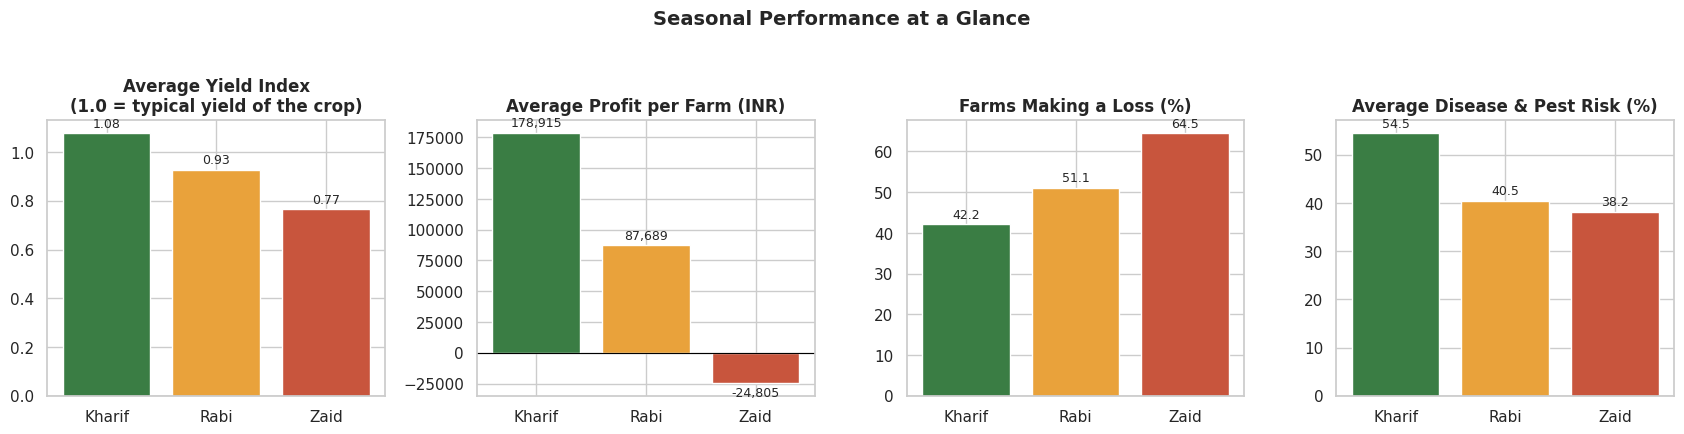

In [13]:
def label_bars(ax, fmt="{:.2f}"):
    for c in ax.containers:
        ax.bar_label(c, labels=[fmt.format(v.get_height()) for v in c], padding=2, fontsize=9)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
panels = [
    ("Avg_Yield_Index",      "Average Yield Index\n(1.0 = typical yield of the crop)", "{:.2f}"),
    ("Avg_Profit_INR",       "Average Profit per Farm (INR)",                         "{:,.0f}"),
    ("Loss_Making_Pct",      "Farms Making a Loss (%)",                                "{:.1f}"),
    ("Avg_Disease_Risk_Pct", "Average Disease & Pest Risk (%)",                        "{:.1f}"),
]
for ax, (col, title, fmt) in zip(axes, panels):
    ax.bar(SEASONS, season_summary[col], color=[PALETTE[s] for s in SEASONS])
    ax.set_title(title); ax.set_xlabel("")
    label_bars(ax, fmt)
    ax.axhline(0, color="black", lw=0.8)
plt.suptitle("Seasonal Performance at a Glance", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

**Insight.** Performance falls steadily from **Kharif to Rabi to Zaid**. Kharif farms have the best yield index and the highest profit. Zaid farms are on average **loss-making**, and about **two out of three Zaid farms lose money**. Disease and pest risk is the one measure that does not follow this order: Kharif is clearly the riskiest season, while Rabi and Zaid are similar.

### 4.2 How do environmental conditions change between seasons?

In [14]:
env_cols = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day", "Soil_Moisture_pct", "Soil_pH"]
df.groupby("Season", observed=True)[env_cols].mean().round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Soil_pH
Season,,,,,,
Kharif,852.11,28.45,71.81,6.79,31.20,6.73
Rabi,435.94,23.49,57.89,7.59,24.05,6.67
Zaid,299.12,31.04,52.01,8.18,19.17,6.69


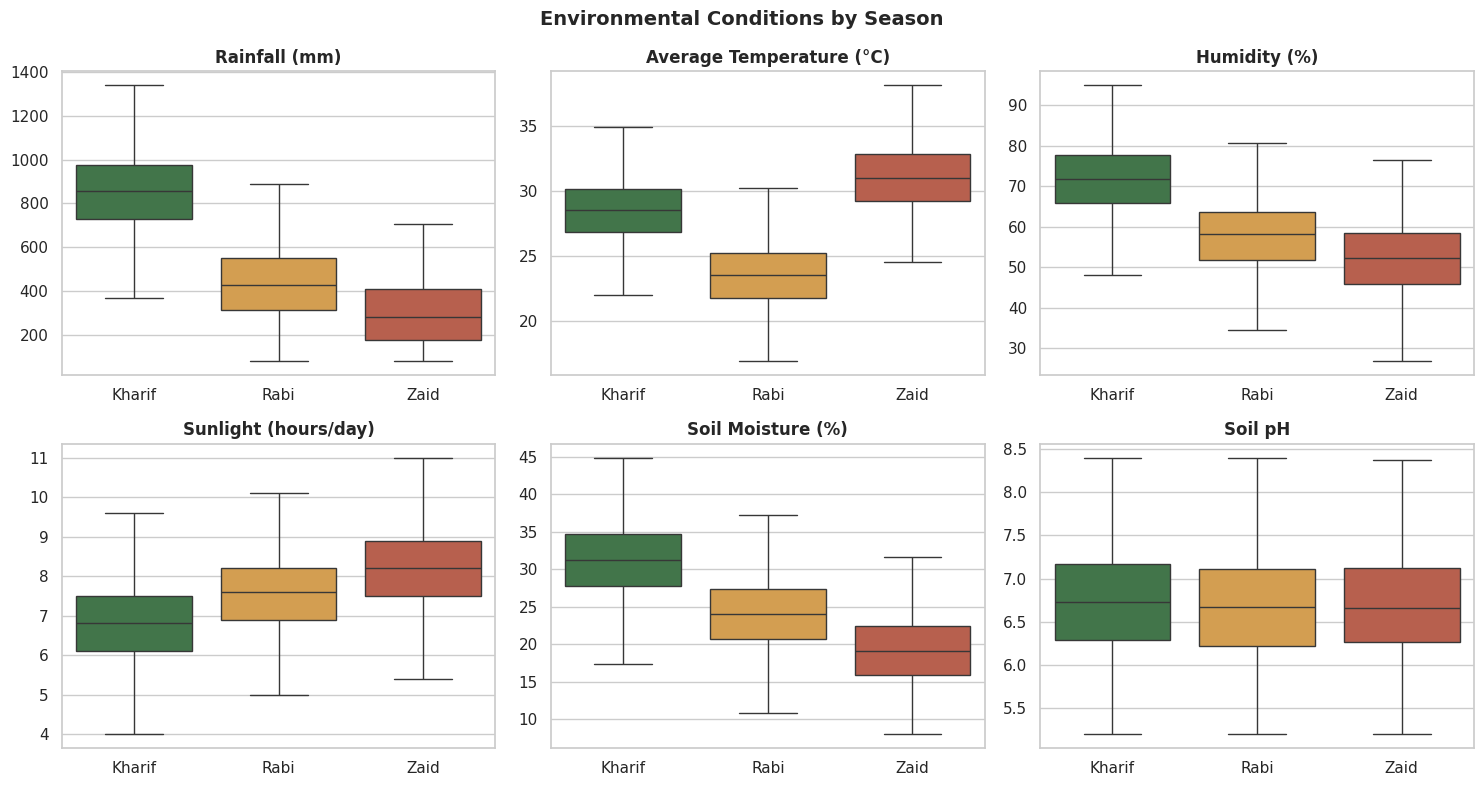

In [15]:
env_titles = {
    "Rainfall_mm": "Rainfall (mm)", "Avg_Temperature_C": "Average Temperature (°C)",
    "Humidity_pct": "Humidity (%)", "Sunlight_Hours_Day": "Sunlight (hours/day)",
    "Soil_Moisture_pct": "Soil Moisture (%)", "Soil_pH": "Soil pH",
}
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), env_cols):
    sns.boxplot(data=df, x="Season", y=col, order=SEASONS, hue="Season", hue_order=SEASONS,
                palette=PALETTE, legend=False, dodge=False, showfliers=False, ax=ax)
    ax.set_title(env_titles[col]); ax.set_xlabel(""); ax.set_ylabel("")
plt.suptitle("Environmental Conditions by Season", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Insight.** The three seasons have very different environments:

* **Kharif** is the wet season: most rainfall (about 850 mm), highest humidity and highest soil moisture, but the least sunlight.
* **Rabi** is cool and moderate: lowest temperature (about 23.5 °C) and about half of Kharif's rainfall.
* **Zaid** is hot and dry: highest temperature (about 31 °C), lowest rainfall, humidity and soil moisture, and the most sunlight.
* **Soil pH is the same in every season**, so it is not a seasonal factor.

### 4.3 Yield across seasons

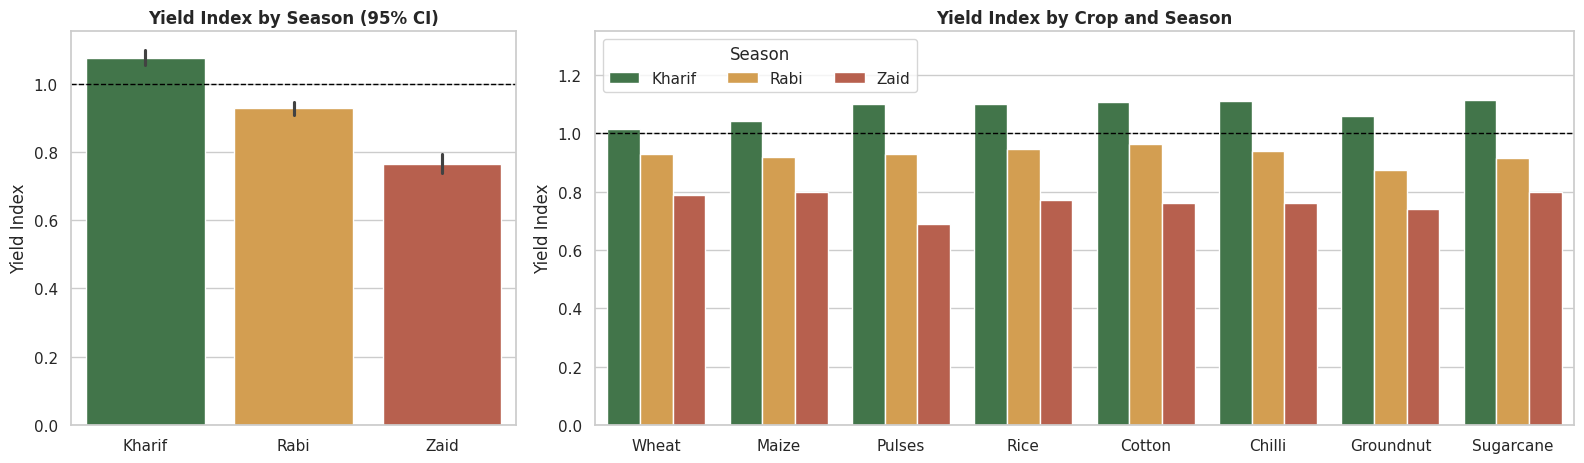

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), gridspec_kw={"width_ratios": [1, 2.2]})

sns.barplot(data=df, x="Season", y="Yield_Index", order=SEASONS, hue="Season", hue_order=SEASONS,
            palette=PALETTE, legend=False, dodge=False, errorbar=("ci", 95), ax=axes[0])
axes[0].axhline(1, color="black", ls="--", lw=1)
axes[0].set_title("Yield Index by Season (95% CI)"); axes[0].set_xlabel(""); axes[0].set_ylabel("Yield Index")

sns.barplot(data=df, x="Crop", y="Yield_Index", hue="Season", hue_order=SEASONS,
            palette=PALETTE, errorbar=None, ax=axes[1])
axes[1].axhline(1, color="black", ls="--", lw=1)
axes[1].set_title("Yield Index by Crop and Season"); axes[1].set_xlabel(""); axes[1].set_ylabel("Yield Index")
axes[1].set_ylim(0, 1.35)
axes[1].legend(title="Season", ncol=3, loc="upper left")
plt.tight_layout()
plt.show()

In [17]:
# Median yield (tonnes/ha) for each crop and season, and does Kharif > Rabi > Zaid hold?
crop_season_yield = df.pivot_table(index="Crop", columns="Season", values="Yield_Tonnes_Ha",
                                   aggfunc="median", observed=True)[SEASONS]
crop_season_yield["Kharif > Rabi > Zaid"] = (crop_season_yield["Kharif"] > crop_season_yield["Rabi"]) & \
                                            (crop_season_yield["Rabi"] > crop_season_yield["Zaid"])
print("Crops following the Kharif > Rabi > Zaid order:", int(crop_season_yield["Kharif > Rabi > Zaid"].sum()), "of", len(crop_season_yield))
crop_season_yield.round(2)

Crops following the Kharif > Rabi > Zaid order: 8 of 8


Season,Kharif,Rabi,Zaid,Kharif > Rabi > Zaid
Crop,,,,
Chilli,1.77,1.56,1.23,True
Cotton,1.44,1.21,0.96,True
Groundnut,1.52,1.30,1.10,True
Maize,3.12,2.82,2.26,True
Pulses,1.09,0.90,0.66,True
Rice,2.88,2.38,1.94,True
Sugarcane,56.65,45.46,38.78,True
Wheat,2.36,2.22,1.84,True


**Insight.** The yield ranking **Kharif > Rabi > Zaid holds for every one of the 8 crops**, so it is a genuine seasonal pattern and not caused by crop mix. On average Kharif yield is about 8% above a crop's normal level, Rabi about 7% below, and Zaid about 23% below.

### 4.4 Economic outcomes

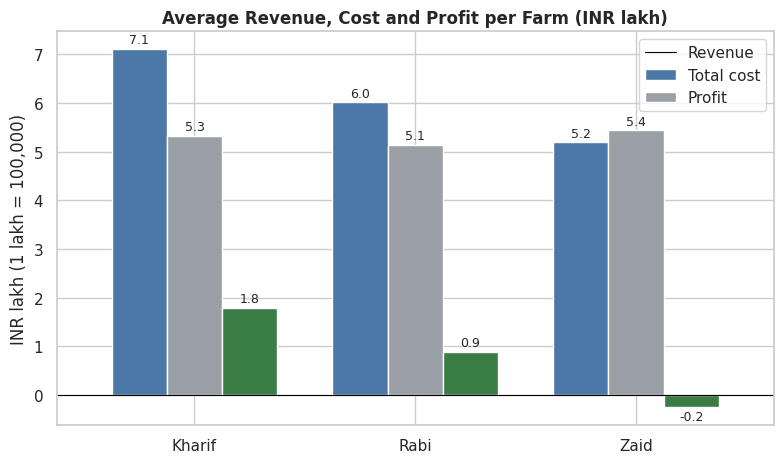

In [18]:
econ = df.groupby("Season", observed=True)[["Revenue_INR", "Total_Cost_INR", "Profit_INR"]].mean().reindex(SEASONS) / 1e5

fig, ax = plt.subplots(figsize=(8, 4.8))
econ.plot(kind="bar", ax=ax, color=["#4C78A8", "#9AA0A6", "#3A7D44"], width=0.75)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Average Revenue, Cost and Profit per Farm (INR lakh)")
ax.set_xlabel(""); ax.set_ylabel("INR lakh (1 lakh = 100,000)")
ax.set_xticklabels(SEASONS, rotation=0)
ax.legend(["Revenue", "Total cost", "Profit"])
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f", padding=2, fontsize=9)
plt.tight_layout()
plt.show()

**Insight.** Costs are almost the same in every season (about ₹5.1 to 5.4 lakh per farm), but **revenue drops from ₹7.1 lakh in Kharif to ₹5.2 lakh in Zaid**. Because cost stays flat while revenue falls, profit swings from positive in Kharif to negative in Zaid. Zaid does not cost less to farm; it simply earns less.

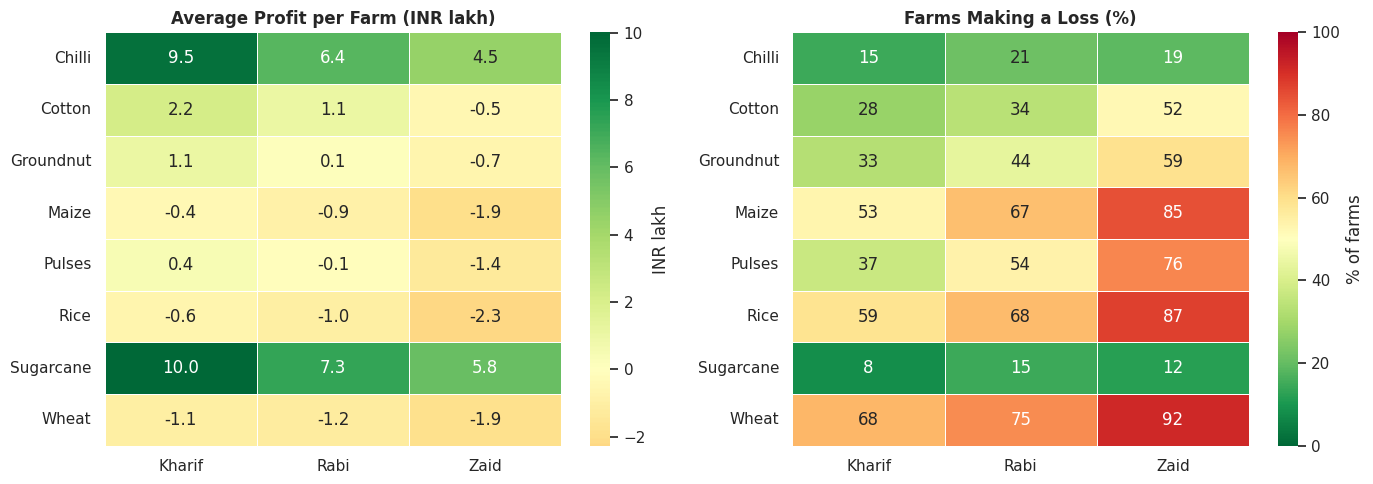

In [19]:
profit_ct = df.pivot_table(index="Crop", columns="Season", values="Profit_INR", aggfunc="mean", observed=True)[SEASONS] / 1e5
loss_ct   = df.pivot_table(index="Crop", columns="Season", values="Loss_Making", aggfunc="mean", observed=True)[SEASONS] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(profit_ct, annot=True, fmt=".1f", cmap="RdYlGn", center=0, linewidths=0.5,
            cbar_kws={"label": "INR lakh"}, ax=axes[0])
axes[0].set_title("Average Profit per Farm (INR lakh)")
sns.heatmap(loss_ct, annot=True, fmt=".0f", cmap="RdYlGn_r", vmin=0, vmax=100, linewidths=0.5,
            cbar_kws={"label": "% of farms"}, ax=axes[1])
axes[1].set_title("Farms Making a Loss (%)")
for ax in axes:
    ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.show()

**Insight.** Every crop earns more in Kharif than in Zaid, but **crop choice matters as much as season**:

* **Sugarcane and Chilli are profitable in all three seasons**, and only 11% to 18% of their farms lose money.
* **Rice, Wheat and Maize lose money on average even in Kharif**, and Wheat has the most loss-making farms (about 74%).
* Cotton and Groundnut are profitable in Kharif and Rabi (Groundnut only just in Rabi) but lose money in Zaid.

### 4.5 Resource usage and water efficiency

In [20]:
res = df.groupby("Season", observed=True).agg(
    Fertilizer_kg_ha=("Fertilizer_kg_ha", "mean"),
    Pesticide_L_ha=("Pesticide_Litre_ha", "mean"),
    Water_m3_per_ha=("Water_per_Ha", "median"),
    Cost_INR_per_ha=("Cost_per_Ha", "median"),
    Seed_Quality=("Seed_Quality_Score", "mean"),
    Water_Efficiency_Index=("Water_Efficiency_Index", "mean"),
).reindex(SEASONS)
res.round(2)

,Fertilizer_kg_ha,Pesticide_L_ha,Water_m3_per_ha,Cost_INR_per_ha,Seed_Quality,Water_Efficiency_Index
Season,,,,,,
Kharif,187.08,5.08,610.15,66741.3,0.82,1.20
Rabi,185.41,5.02,595.45,66281.4,0.83,1.05
Zaid,184.64,5.17,619.05,66743.2,0.82,0.85


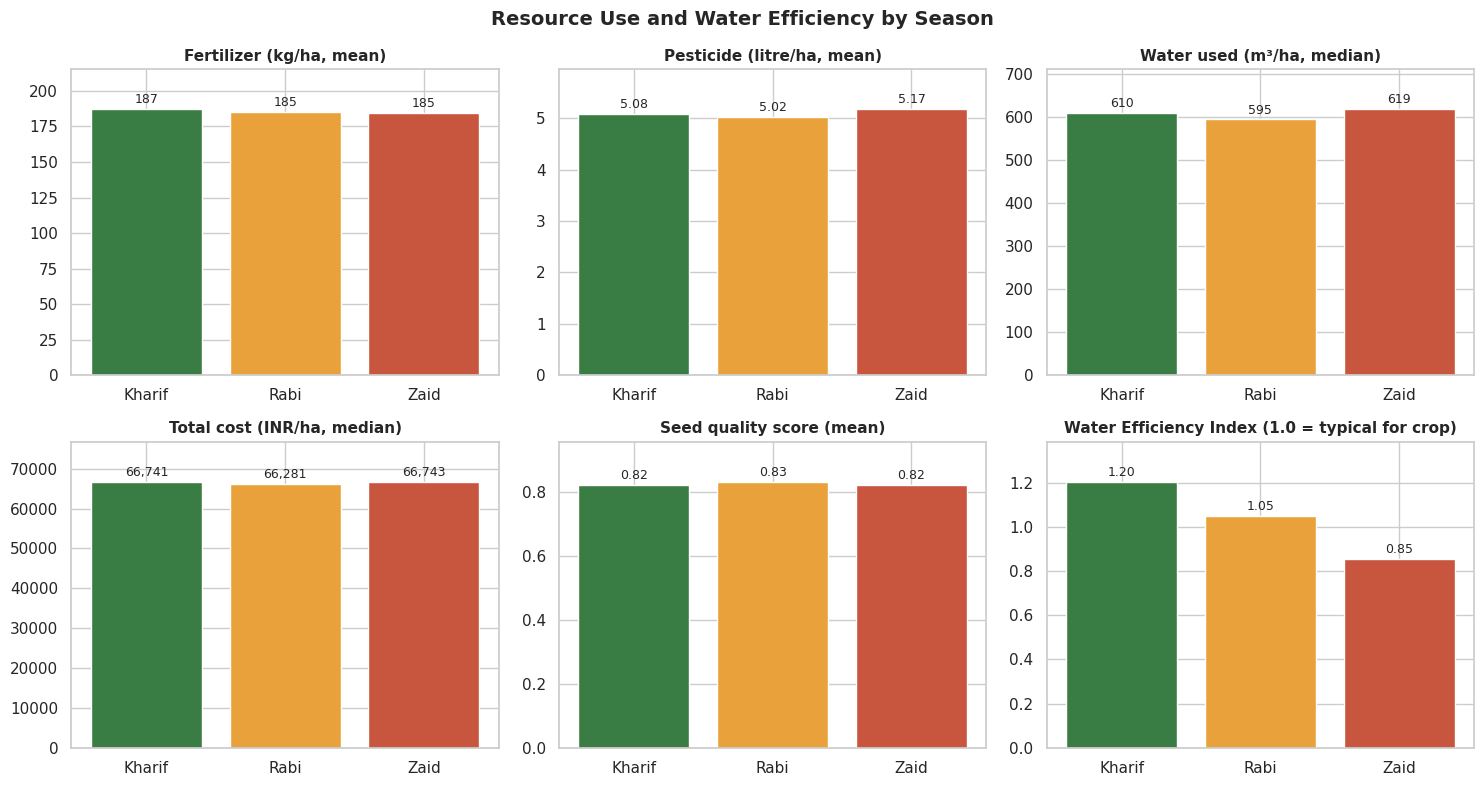

In [21]:
res_titles = {
    "Fertilizer_kg_ha": "Fertilizer (kg/ha, mean)", "Pesticide_L_ha": "Pesticide (litre/ha, mean)",
    "Water_m3_per_ha": "Water used (m³/ha, median)", "Cost_INR_per_ha": "Total cost (INR/ha, median)",
    "Seed_Quality": "Seed quality score (mean)", "Water_Efficiency_Index": "Water Efficiency Index (1.0 = typical for crop)",
}
fmts = {"Fertilizer_kg_ha": "{:.0f}", "Pesticide_L_ha": "{:.2f}", "Water_m3_per_ha": "{:,.0f}",
        "Cost_INR_per_ha": "{:,.0f}", "Seed_Quality": "{:.2f}", "Water_Efficiency_Index": "{:.2f}"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), res.columns):
    ax.bar(SEASONS, res[col], color=[PALETTE[s] for s in SEASONS])
    ax.set_title(res_titles[col], fontsize=11); ax.set_xlabel("")
    ax.set_ylim(0, res[col].max() * 1.15)
    label_bars(ax, fmts[col])
plt.suptitle("Resource Use and Water Efficiency by Season", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Insight.** Farmers use **almost identical amounts of fertilizer, pesticide, seed quality, water and money per hectare in every season** (water is only marginally higher in Zaid, at about 619 vs 610 m³/ha in Kharif). But **water efficiency falls steadily from Kharif to Zaid** (index 1.20, 1.05, 0.85): a Zaid farm uses the same inputs and water and gets clearly less output. Inputs are not adjusted to the season, and the season does not reward them equally.

### 4.6 Disease and pest risk

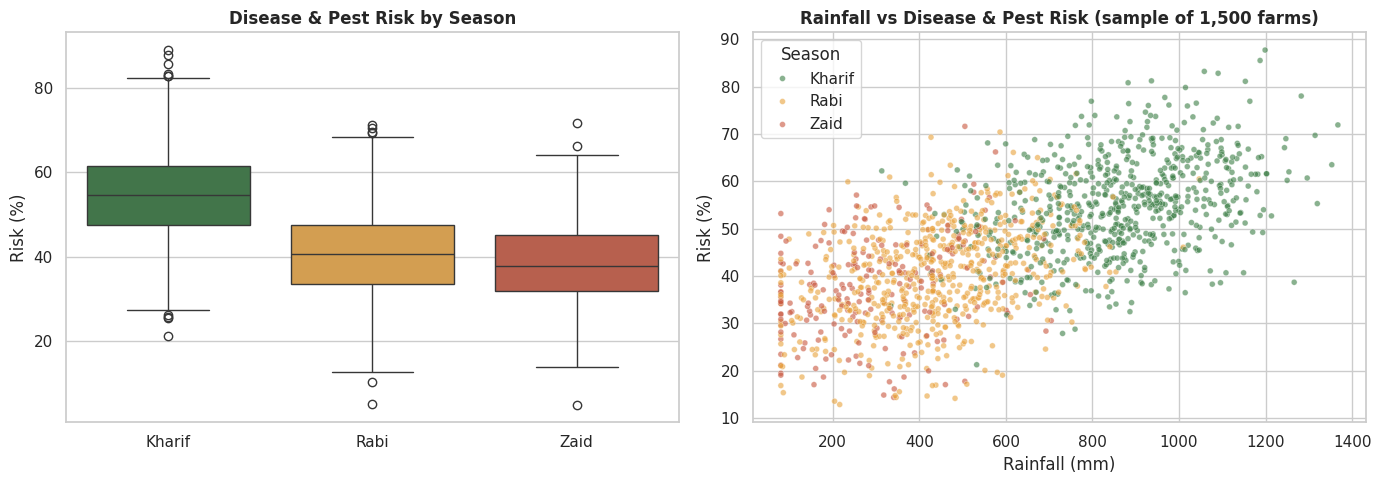

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Season", y="Disease_Pest_Risk_pct", order=SEASONS, hue="Season", hue_order=SEASONS,
            palette=PALETTE, legend=False, dodge=False, ax=axes[0])
axes[0].set_title("Disease & Pest Risk by Season"); axes[0].set_xlabel(""); axes[0].set_ylabel("Risk (%)")

sns.scatterplot(data=df.sample(1500, random_state=1), x="Rainfall_mm", y="Disease_Pest_Risk_pct",
                hue="Season", hue_order=SEASONS, palette=PALETTE, alpha=0.6, s=18, ax=axes[1])
axes[1].set_title("Rainfall vs Disease & Pest Risk (sample of 1,500 farms)")
axes[1].set_xlabel("Rainfall (mm)"); axes[1].set_ylabel("Risk (%)")
plt.tight_layout()
plt.show()

In [23]:
risk_drivers = ["Rainfall_mm", "Humidity_pct", "Soil_Moisture_pct", "Avg_Temperature_C", "Sunlight_Hours_Day"]
drv = df[risk_drivers + ["Disease_Pest_Risk_pct"]].corr(method="spearman")["Disease_Pest_Risk_pct"].drop("Disease_Pest_Risk_pct")
print("Spearman correlation of each condition with Disease & Pest Risk:")
drv.sort_values(ascending=False).round(2).to_frame("Correlation")

Spearman correlation of each condition with Disease & Pest Risk:


,Correlation
Rainfall_mm,0.63
Humidity_pct,0.55
Soil_Moisture_pct,0.40
Avg_Temperature_C,0.26
Sunlight_Hours_Day,-0.25


**Insight.** Disease and pest risk is driven by **wetness**: rainfall (correlation about 0.63), humidity (about 0.55) and soil moisture (about 0.40) are the strongest links. That explains why Kharif, the wettest season, has the highest risk (about 54%) while the drier Rabi and Zaid have about 38% to 40%. Sunlight has a negative link, meaning sunnier conditions go with lower risk.

Risk is **not** what makes Zaid unprofitable: Zaid has the *lowest* disease risk but the lowest yield.

## 5. Relationships between conditions and outcomes

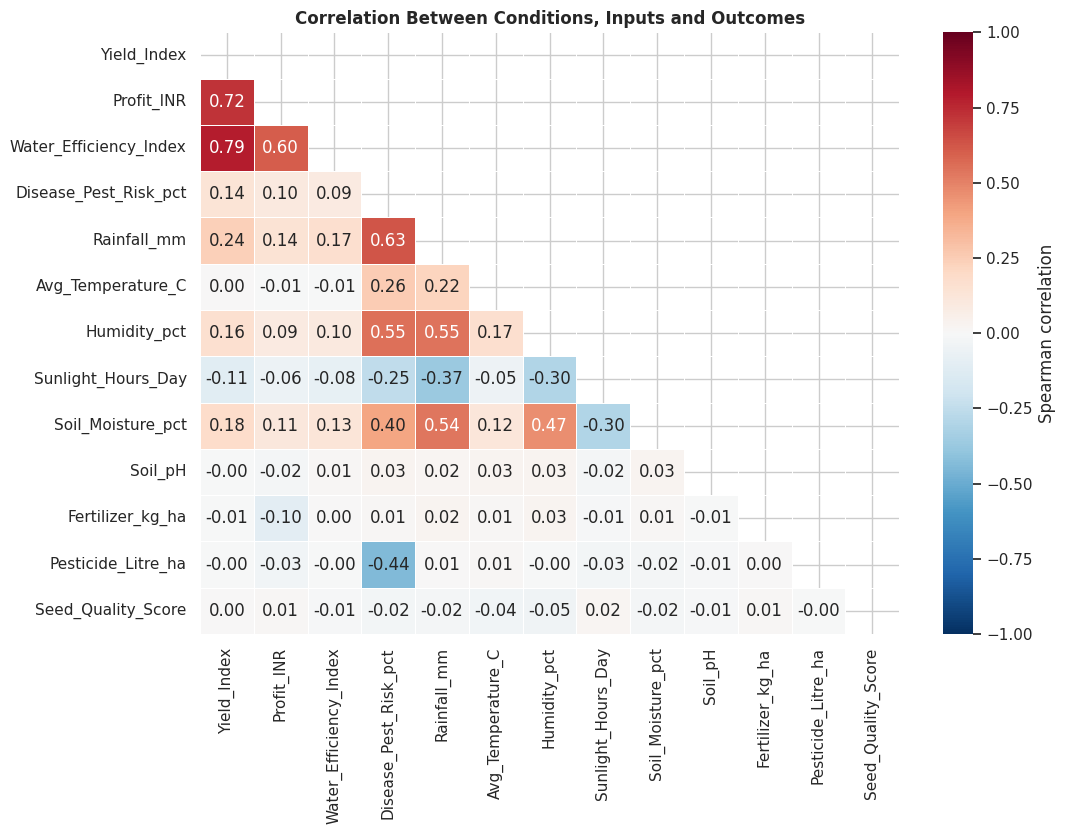

In [24]:
corr_cols = ["Yield_Index", "Profit_INR", "Water_Efficiency_Index", "Disease_Pest_Risk_pct",
             "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day",
             "Soil_Moisture_pct", "Soil_pH", "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Seed_Quality_Score"]
corr = df[corr_cols].corr(method="spearman")      # Spearman handles skewed data and outliers

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 8.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"label": "Spearman correlation"}, ax=ax)
ax.set_title("Correlation Between Conditions, Inputs and Outcomes")
plt.tight_layout()
plt.show()

In [25]:
# Do the same relationships appear inside each season?
drivers = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day",
           "Soil_Moisture_pct", "Fertilizer_kg_ha", "Seed_Quality_Score"]
within = pd.DataFrame({
    s: df[df["Season"] == s][drivers + ["Yield_Index"]].corr(method="spearman")["Yield_Index"].drop("Yield_Index")
    for s in SEASONS
})
print("Spearman correlation with Yield Index, inside each season:")
within.round(2)

Spearman correlation with Yield Index, inside each season:


,Kharif,Rabi,Zaid
Rainfall_mm,-0.19,0.27,0.31
Avg_Temperature_C,-0.09,0.16,-0.18
Humidity_pct,-0.01,-0.01,0.03
Sunlight_Hours_Day,0.02,-0.04,0.06
Soil_Moisture_pct,0.06,-0.01,-0.02
Fertilizer_kg_ha,-0.01,-0.02,-0.01
Seed_Quality_Score,0.03,-0.01,-0.02


**Insight.**

* **Yield and profit move together strongly** (correlation about 0.72), and **yield is closely tied to water efficiency** (about 0.79).
* Across all farms, **rainfall (about 0.24), soil moisture (about 0.18) and humidity (about 0.16) show a weak positive link with yield**. Temperature, fertilizer, pesticide and seed quality show essentially **no link** with yield.
* **Inside each season, rainfall is the only variable with a noticeable link, and it behaves differently.** It is positive in the drier seasons (Rabi 0.27, Zaid 0.31) but slightly negative in the wettest season (Kharif -0.19). One possible reading is that extra water helps when it is scarce and hurts when it is already plentiful. This is a hypothesis to test, not a proven cause.
* The seasonal yield gap is therefore **not explained by any single measured variable**. It reflects the combined season effect (wetter and milder Kharif vs hot and dry Zaid) rather than something more fertilizer would fix.

## 6. Is the pattern consistent across irrigation methods and states?
### 6.1 Irrigation method

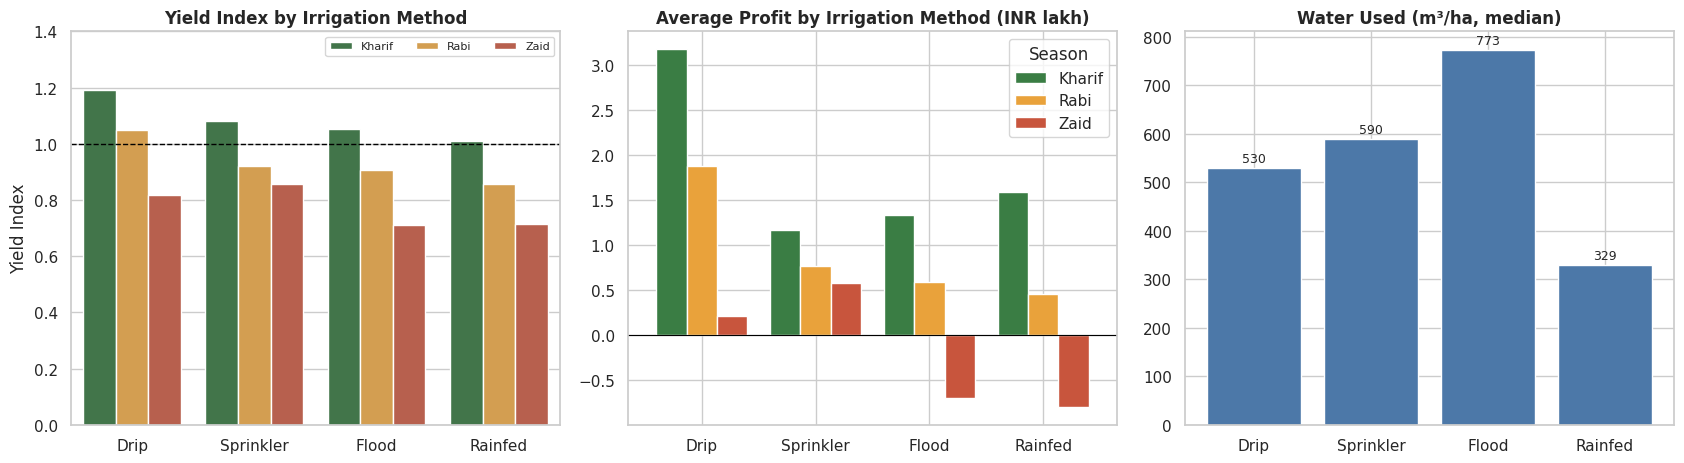

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
irr_order = ["Drip", "Sprinkler", "Flood", "Rainfed"]

sns.barplot(data=df, x="Irrigation_Method", y="Yield_Index", order=irr_order, hue="Season", hue_order=SEASONS,
            palette=PALETTE, errorbar=None, ax=axes[0])
axes[0].axhline(1, color="black", ls="--", lw=1)
axes[0].set_title("Yield Index by Irrigation Method"); axes[0].set_xlabel(""); axes[0].set_ylabel("Yield Index")
axes[0].set_ylim(0, 1.4); axes[0].legend(ncol=3, loc="upper right", fontsize=8, title=None)

irr_profit = df.pivot_table(index="Irrigation_Method", columns="Season", values="Profit_INR",
                            aggfunc="mean", observed=True).loc[irr_order, SEASONS] / 1e5
irr_profit.plot(kind="bar", ax=axes[1], color=[PALETTE[s] for s in SEASONS], width=0.8)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Average Profit by Irrigation Method (INR lakh)"); axes[1].set_xlabel("")
axes[1].set_xticklabels(irr_order, rotation=0)

water_irr = df.groupby("Irrigation_Method")["Water_per_Ha"].median().loc[irr_order]
axes[2].bar(irr_order, water_irr, color="#4C78A8")
axes[2].set_title("Water Used (m³/ha, median)"); axes[2].set_xlabel("")
label_bars(axes[2], "{:,.0f}")
plt.tight_layout()
plt.show()

In [27]:
irr_profit.round(2)

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,3.17,1.88,0.21
Sprinkler,1.17,0.77,0.58
Flood,1.33,0.59,-0.70
Rainfed,1.59,0.45,-0.79


**Insight.**

* **Drip irrigation gives the best yield and the highest profit in Kharif and Rabi** (about ₹3.2 lakh and ₹1.9 lakh), and uses about a third less water per hectare than flood irrigation.
* **Zaid is the exception:** sprinkler irrigation gives both the best yield (index about 0.86 vs 0.82 for drip) and the best profit (about ₹0.58 lakh vs ₹0.21 lakh for drip).
* **Flood irrigation uses the most water** (about 770 m³/ha), and together with rainfed farming it loses money in Zaid (about -₹0.7 to -0.8 lakh).
* **Every irrigation method still follows Kharif > Rabi > Zaid** for yield, so irrigation reduces the seasonal gap but does not remove it.

### 6.2 States

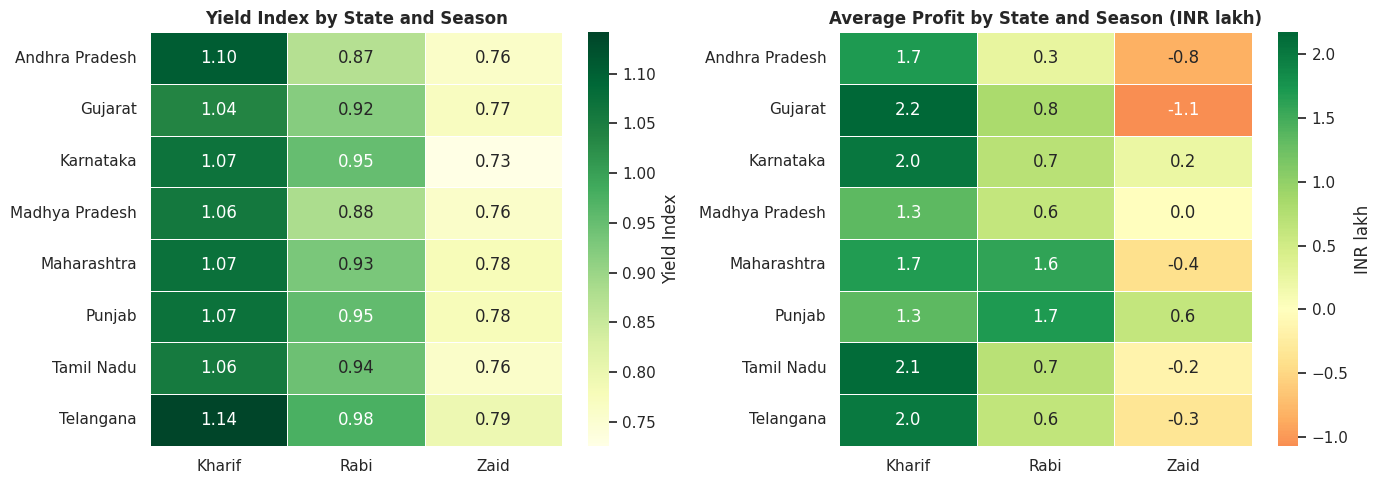

In [28]:
state_yield  = df.pivot_table(index="State", columns="Season", values="Yield_Index", aggfunc="mean", observed=True)[SEASONS]
state_profit = df.pivot_table(index="State", columns="Season", values="Profit_INR", aggfunc="mean", observed=True)[SEASONS] / 1e5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(state_yield, annot=True, fmt=".2f", cmap="YlGn", linewidths=0.5, ax=axes[0], cbar_kws={"label": "Yield Index"})
axes[0].set_title("Yield Index by State and Season")
sns.heatmap(state_profit, annot=True, fmt=".1f", cmap="RdYlGn", center=0, linewidths=0.5, ax=axes[1], cbar_kws={"label": "INR lakh"})
axes[1].set_title("Average Profit by State and Season (INR lakh)")
for ax in axes:
    ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [29]:
consistency = pd.DataFrame({
    "Best season (yield)":  state_yield.idxmax(axis=1),
    "Best season (profit)": state_profit.idxmax(axis=1),
    "Yield order Kharif>Rabi>Zaid": (state_yield["Kharif"] > state_yield["Rabi"]) & (state_yield["Rabi"] > state_yield["Zaid"]),
})
consistency

,Best season (yield),Best season (profit),Yield order Kharif>Rabi>Zaid
State,,,
Andhra Pradesh,Kharif,Kharif,True
Gujarat,Kharif,Kharif,True
Karnataka,Kharif,Kharif,True
Madhya Pradesh,Kharif,Kharif,True
Maharashtra,Kharif,Kharif,True
Punjab,Kharif,Rabi,True
Tamil Nadu,Kharif,Kharif,True
Telangana,Kharif,Kharif,True


**Insight.** The **yield order Kharif > Rabi > Zaid holds in all 8 states**, so the pattern is widespread and not driven by one region. Profit is more varied:

* **Punjab is the one state where Rabi earns more than Kharif** (about ₹1.7 lakh vs ₹1.3 lakh). This fits Punjab's known wheat-based Rabi cropping, although the dataset shows Wheat as loss-making on average, so this should be checked further.
* **Maharashtra's Rabi profit is almost as high as its Kharif profit**, so the Kharif advantage is smallest there.
* Zaid is loss-making on average in Andhra Pradesh, Gujarat, Maharashtra, Tamil Nadu and Telangana, and break-even or positive in Karnataka, Madhya Pradesh and Punjab.

## 7. Are the differences statistically significant?
Because profit and yield are skewed, we use the **Kruskal-Wallis test** (non-parametric ANOVA) to compare the three seasons, then pairwise **Mann-Whitney U** tests with a Bonferroni correction. A p-value below 0.05 means the difference is very unlikely to be chance.

In [30]:
def fmt_p(p):
    return "< 0.001" if p < 0.001 else f"{p:.3f}"

metrics = {
    "Yield_Index": "Yield Index",
    "Profit_INR": "Profit (INR)",
    "Water_Efficiency_Index": "Water Efficiency Index",
    "Disease_Pest_Risk_pct": "Disease & Pest Risk (%)",
    "Rainfall_mm": "Rainfall (mm)",
    "Avg_Temperature_C": "Temperature (°C)",
    "Fertilizer_kg_ha": "Fertilizer (kg/ha)",
    "Pesticide_Litre_ha": "Pesticide (litre/ha)",
    "Cost_per_Ha": "Cost per hectare (INR)",
}
rows = []
for col, label in metrics.items():
    groups = [df.loc[df["Season"] == s, col] for s in SEASONS]
    H, p = stats.kruskal(*groups)
    row = {"Metric": label, "H statistic": round(H, 1), "p-value": fmt_p(p), "Significant (p<0.05)": "Yes" if p < 0.05 else "No"}
    for a, b in combinations(SEASONS, 2):
        pp = min(stats.mannwhitneyu(df.loc[df["Season"] == a, col], df.loc[df["Season"] == b, col]).pvalue * 3, 1.0)
        row[f"{a} vs {b}"] = fmt_p(pp)
    rows.append(row)
pd.DataFrame(rows).set_index("Metric")

,H statistic,p-value,Significant (p<0.05),Kharif vs Rabi,Kharif vs Zaid,Rabi vs Zaid
Metric,,,,,,
Yield Index,254.1,< 0.001,Yes,< 0.001,< 0.001,< 0.001
Profit (INR),101.9,< 0.001,Yes,< 0.001,< 0.001,< 0.001
Water Efficiency Index,134.9,< 0.001,Yes,< 0.001,< 0.001,< 0.001
Disease & Pest Risk (%),1430.9,< 0.001,Yes,< 0.001,< 0.001,< 0.001
Rainfall (mm),2600.1,< 0.001,Yes,< 0.001,< 0.001,< 0.001
Temperature (°C),2386.0,< 0.001,Yes,< 0.001,< 0.001,< 0.001
Fertilizer (kg/ha),1.1,0.589,No,1.000,0.948,1.000
Pesticide (litre/ha),2.4,0.306,No,0.677,1.000,0.547
Cost per hectare (INR),5.0,0.081,No,0.088,1.000,0.569


In [31]:
# Is the share of loss-making farms different across seasons? (chi-square test)
table = pd.crosstab(df["Season"], df["Loss_Making"]).reindex(SEASONS)
table.columns = ["Profitable", "Loss-making"]
chi2, p, dof, _ = stats.chi2_contingency(table)
print(f"Chi-square = {chi2:.1f}, degrees of freedom = {dof}, p-value {fmt_p(p)}")
table

Chi-square = 92.6, degrees of freedom = 2, p-value < 0.001


,Profitable,Loss-making
Season,,
Kharif,1028,751
Rabi,795,832
Zaid,211,383


**Insight.**

* Yield, profit, water efficiency, disease risk, rainfall and temperature **all differ significantly between seasons, and every pair of seasons differs from each other** on each of these measures. The share of loss-making farms also differs significantly (chi-square test).
* **Fertilizer, pesticide and cost per hectare do not differ significantly between seasons.** This confirms that farmers apply the same inputs in every season, even though results differ a lot.

Statistical significance shows the differences are real. It does not, on its own, show *why* they occur.

## 8. Unusual and unexpected patterns

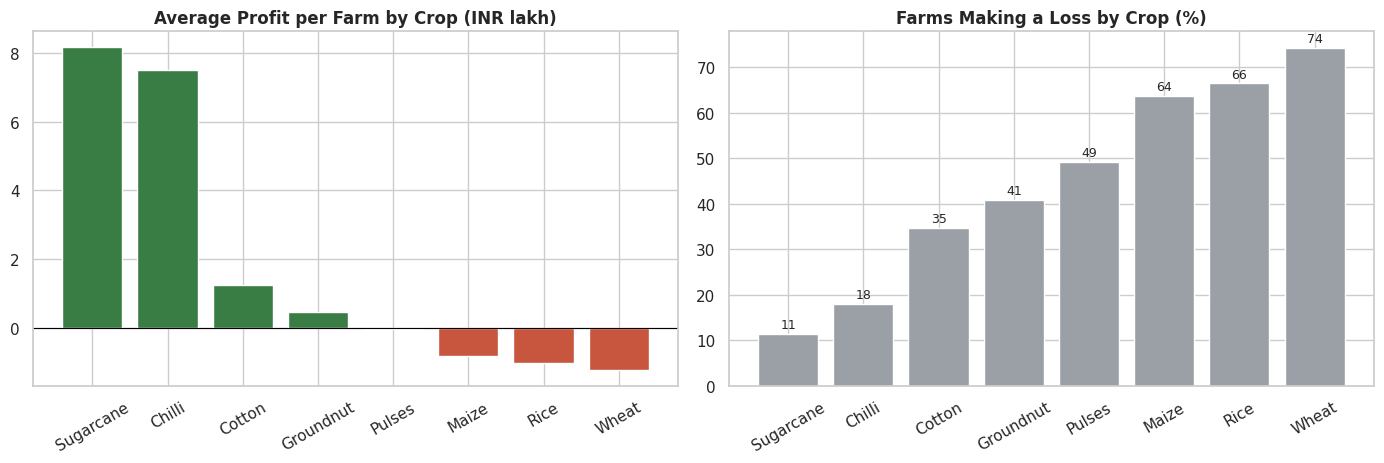

,Avg_Profit_INR,Avg_Profit_per_Ha,Loss_Making_Pct,Avg_Price_INR_per_tonne
Crop,,,,
Sugarcane,817188.0,97169.9,11.5,3490.3
Chilli,750878.3,92123.1,18.0,103372.9
Cotton,124546.9,16354.2,34.6,67921.1
Groundnut,44858.1,7443.7,40.8,56310.1
Pulses,-4238.1,-693.4,49.2,71431.6
Maize,-83978.3,-10203.1,63.7,20990.5
Rice,-102213.5,-13137.5,66.4,22023.1
Wheat,-123398.3,-15968.8,74.1,23829.4


In [32]:
crop_econ = df.groupby("Crop").agg(
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Profit_per_Ha=("Profit_per_Ha", "mean"),
    Loss_Making_Pct=("Loss_Making", "mean"),
    Avg_Price_INR_per_tonne=("Market_Price_INR_Tonne", "mean"),
).sort_values("Avg_Profit_INR", ascending=False)
crop_econ["Loss_Making_Pct"] *= 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
colors = ["#3A7D44" if v > 0 else "#C8553D" for v in crop_econ["Avg_Profit_INR"]]
axes[0].bar(crop_econ.index, crop_econ["Avg_Profit_INR"] / 1e5, color=colors)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Average Profit per Farm by Crop (INR lakh)"); axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)
axes[1].bar(crop_econ.index, crop_econ["Loss_Making_Pct"], color="#9AA0A6")
axes[1].set_title("Farms Making a Loss by Crop (%)"); axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)
label_bars(axes[1], "{:.0f}")
plt.tight_layout()
plt.show()

crop_econ.round(1)

In [33]:
print(f"Overall share of loss-making farms: {df['Loss_Making'].mean():.1%}")
kharif_loss_crops = profit_ct.index[profit_ct["Kharif"] < 0].tolist()
print("Crops with negative AVERAGE profit even in Kharif (best season):", kharif_loss_crops)
print()
print("Correlation of fertilizer with yield index :", round(df["Fertilizer_kg_ha"].corr(df["Yield_Index"], method="spearman"), 3))
print("Correlation of fertilizer with profit      :", round(df["Fertilizer_kg_ha"].corr(df["Profit_INR"], method="spearman"), 3))
print("Correlation of seed quality with yield idx :", round(df["Seed_Quality_Score"].corr(df["Yield_Index"], method="spearman"), 3))

Overall share of loss-making farms: 49.1%
Crops with negative AVERAGE profit even in Kharif (best season): ['Maize', 'Rice', 'Wheat']

Correlation of fertilizer with yield index : -0.006
Correlation of fertilizer with profit      : -0.102
Correlation of seed quality with yield idx : 0.003


**Unusual observations**

1. **About half of all farms (49%) lose money.** Rice, Wheat and Maize, which are among the most common crops, have negative average profit even in their best season. Their market prices are low (about ₹21,000 to 24,000 per tonne) compared with their costs.
2. **Sugarcane and Chilli carry the profits.** Sugarcane's price per tonne is the lowest, but its very high tonnage per hectare makes it the most profitable crop. Chilli's high price does the same.
3. **More fertilizer does not mean more yield or profit.** Fertilizer has about zero correlation with yield and a slightly negative one with profit, suggesting money is spent on inputs that are not paying back.
4. **Zaid is not cheaper, only weaker.** Costs are the same as in the other seasons, yet output is lowest.
5. **Punjab is the only state where Rabi beats Kharif**, and **sprinkler beats drip in Zaid**. Both are worth a closer look.
6. **Data-quality flag:** district names do not match their states, so district-level analysis would be unreliable.

## 9. Conclusions
### Key findings
1. **Kharif is the strongest season, Rabi is in the middle and Zaid is the weakest.** This holds for yield in every crop and every state. Average profit falls from about ₹1.79 lakh (Kharif) to ₹0.88 lakh (Rabi) to **−₹0.25 lakh (Zaid)**, and the share of loss-making farms rises from 42% to 51% to **64%**.
2. **The seasons have very different climates.** Kharif is wet and humid, Rabi is cool, and Zaid is hot, dry and sunny.
3. **Costs and inputs do not change by season, but revenue does.** That is why Zaid falls into losses.
4. **Disease and pest risk follows wetness**, and is highest in Kharif, but it does not explain the profit gap.
5. **Crop choice matters as much as season.** Sugarcane and Chilli are profitable in all seasons; Rice, Wheat and Maize are not.
6. **Drip irrigation gives the best yield and profit in Kharif and Rabi; sprinkler is best in Zaid.** Flood irrigation uses the most water and loses money in Zaid.

